# VGG19 CommonPipelineV2 - Grad-CAM++ And FACT Deletion

Notebook tao hinh Grad-CAM++ threshold overlay va FACT deletion batch cho VGG19
(CommonPipelineV2 / no_contrast / effboost1.5 / 3-class overall).

Model weights: `best.weights.h5` (save_weights_only=True).
Classes: `normal`, `pneumonia_only`, `effusion_only`.

In [1]:
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

SEED = 42
IMAGE_SIZE = 256
BATCH_SIZE = 16
CLASS_NAMES = ["normal", "pneumonia_only", "effusion_only"]
CLASS_TO_INDEX = {name: idx for idx, name in enumerate(CLASS_NAMES)}
GRADCAM_LAYER = "block5_conv4"
HEATMAP_THRESHOLD = 0.45
OVERLAY_ALPHA = 0.55
DROPOUT_RATE = 0.30

# Model weights path (save_weights_only=True -> .h5)
MODEL_WEIGHT_CANDIDATES = [
    Path("/kaggle/input/datasets/thuanminh1310/test-anh-sach/train_overall_vgg19_common_pipeline_v2_256_caffe_no_contrast_effboost15_adamw_smooth_threshold/models/vgg19/best.weights.h5"),
    Path("/kaggle/input/test-anh-sach/train_overall_vgg19_common_pipeline_v2_256_caffe_no_contrast_effboost15_adamw_smooth_threshold/models/vgg19/best.weights.h5"),
]

# Dataset roots
DATASET_ROOT_CANDIDATES = [
    "/kaggle/input/datasets/thuanminh1310/datasetspbl4/pbl4_main_aux_datasets",
    "/kaggle/working/pbl4_main_aux_datasets",
    "/kaggle/input/pbl4-main-aux-datasets",
]
NIH_IMAGE_ROOT_CANDIDATES = [
    "/kaggle/input/datasets/organizations/nih-chest-xrays/data",
    "/kaggle/input/nih-chest-xrays/data",
    "/kaggle/input/chest-xray14/images",
]
EXTERNAL_ROOT_CANDIDATES = [
    "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray",
    "/kaggle/input/chest-xray-pneumonia/chest_xray",
]
TEST_MANIFEST_NAME = "main_test_70_15_15.csv"

OUTPUT_DIR = Path("/kaggle/working/report_vgg19_commonv2_gradcampp_fact")
FIGURE_DIR = OUTPUT_DIR / "figures"
ARTIFACT_DIR = OUTPUT_DIR / "artifacts"
for directory in [OUTPUT_DIR, FIGURE_DIR, ARTIFACT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

MODEL_WEIGHT_PATH = next((p for p in MODEL_WEIGHT_CANDIDATES if p.exists()), MODEL_WEIGHT_CANDIDATES[0])
print("TensorFlow:", tf.__version__)
print("MODEL_WEIGHT_PATH exists:", MODEL_WEIGHT_PATH.exists(), MODEL_WEIGHT_PATH)
if not MODEL_WEIGHT_PATH.exists():
    raise FileNotFoundError(MODEL_WEIGHT_PATH)


2026-06-09 04:33:09.879673: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780979590.037693      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780979590.082301      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780979590.450113      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780979590.450148      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780979590.450151      23 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
MODEL_WEIGHT_PATH exists: True /kaggle/input/datasets/thuanminh1310/test-anh-sach/train_overall_vgg19_common_pipeline_v2_256_caffe_no_contrast_effboost15_adamw_smooth_threshold/models/vgg19/best.weights.h5


In [2]:
VALID_IMAGE_EXTS = {".png", ".jpg", ".jpeg"}
IMAGE_INDEX_CACHE = {}


def find_existing_dir(candidates):
    for candidate in candidates:
        p = Path(candidate)
        if p.exists():
            return p
    raise FileNotFoundError(f"Could not find any valid directory from: {candidates}")


def build_image_index(search_root):
    image_map = {}
    duplicate_names = set()
    for image_path in sorted(p for p in search_root.rglob("*") if p.suffix.lower() in VALID_IMAGE_EXTS):
        name = image_path.name
        if name in image_map and image_map[name] != str(image_path):
            duplicate_names.add(name)
            continue
        image_map.setdefault(name, str(image_path))
    return image_map, duplicate_names


def get_cached_image_index(search_root):
    key = str(search_root)
    if key not in IMAGE_INDEX_CACHE:
        IMAGE_INDEX_CACHE[key] = build_image_index(search_root)
    return IMAGE_INDEX_CACHE[key]


def remap_relative_to_root(original_path, target_root, anchor_name):
    path_obj = Path(str(original_path))
    if path_obj.exists():
        return str(path_obj)
    parts = list(path_obj.parts)
    if anchor_name in parts:
        relative_parts = parts[parts.index(anchor_name) + 1:]
        candidate = target_root.joinpath(*relative_parts)
        if candidate.exists():
            return str(candidate)
    return str(original_path)


def resolve_manifest_paths(frame, nih_root, external_root):
    df = frame.copy()
    df["resolved_path"] = df["resolved_path"].astype(str)
    df["resolved_path"] = np.where(
        df["source"].eq("nih"),
        df["resolved_path"].map(lambda p: remap_relative_to_root(p, nih_root, "data")),
        df["resolved_path"],
    )
    df["resolved_path"] = np.where(
        df["source"].eq("chest_xray_pneumonia"),
        df["resolved_path"].map(lambda p: remap_relative_to_root(p, external_root, "chest_xray")),
        df["resolved_path"],
    )
    exists_mask = df["resolved_path"].map(lambda x: Path(str(x)).exists())
    if not exists_mask.all():
        if df.loc[~exists_mask, "source"].eq("nih").any():
            nih_map, _ = get_cached_image_index(nih_root)
            missing_mask = df["source"].eq("nih") & ~exists_mask
            df.loc[missing_mask, "resolved_path"] = df.loc[missing_mask, "resolved_path"].map(
                lambda p: nih_map.get(Path(str(p)).name, str(p))
            )
        exists_mask = df["resolved_path"].map(lambda x: Path(str(x)).exists())
        if df.loc[~exists_mask, "source"].eq("chest_xray_pneumonia").any():
            ext_map, _ = get_cached_image_index(external_root)
            missing_mask = df["source"].eq("chest_xray_pneumonia") & ~exists_mask
            df.loc[missing_mask, "resolved_path"] = df.loc[missing_mask, "resolved_path"].map(
                lambda p: ext_map.get(Path(str(p)).name, str(p))
            )
    final_missing = ~df["resolved_path"].map(lambda x: Path(str(x)).exists())
    if final_missing.any():
        examples = df.loc[final_missing, ["source", "resolved_path"]].head(5).to_dict("records")
        raise FileNotFoundError(f"Could not resolve some image paths. Examples: {examples}")
    df["image_path"] = df["resolved_path"]
    return df


def load_manifest(manifest_path, class_to_index, nih_root, external_root):
    df = pd.read_csv(manifest_path)
    if "class_index" not in df.columns:
        df["class_index"] = df["class_name"].map(class_to_index)
    if df["class_index"].isna().any():
        bad = sorted(df.loc[df["class_index"].isna(), "class_name"].dropna().unique().tolist())
        raise ValueError(f"Unknown class names: {bad}")
    df["class_index"] = df["class_index"].astype(int)
    return resolve_manifest_paths(df, nih_root, external_root).reset_index(drop=True)


DATASET_ROOT = find_existing_dir(DATASET_ROOT_CANDIDATES)
MANIFEST_DIR = DATASET_ROOT / "manifests"
NIH_IMAGE_ROOT = find_existing_dir(NIH_IMAGE_ROOT_CANDIDATES)
EXTERNAL_ROOT = find_existing_dir(EXTERNAL_ROOT_CANDIDATES)

test_df = load_manifest(MANIFEST_DIR / TEST_MANIFEST_NAME, CLASS_TO_INDEX, NIH_IMAGE_ROOT, EXTERNAL_ROOT)
paths = test_df["resolved_path"].values
labels = test_df["class_index"].astype(np.int32).values

print("Test set:", len(test_df))
from IPython.display import display
display(test_df["class_name"].value_counts())


Test set: 2427


class_name
normal            1699
pneumonia_only     364
effusion_only      364
Name: count, dtype: int64

In [3]:
layers = tf.keras.layers


def build_vgg19(input_shape, dropout_rate=DROPOUT_RATE):
    inputs = layers.Input(shape=input_shape, name="image")
    backbone = tf.keras.applications.VGG19(include_top=False, weights=None, input_tensor=inputs)
    x = layers.GlobalAveragePooling2D(name="vgg_gap")(backbone.output)
    x = layers.Dropout(dropout_rate, name="vgg_dropout")(x)
    x = layers.Dense(256, activation="relu", name="vgg_dense_256")(x)
    x = layers.Dropout(dropout_rate, name="vgg_dropout_2")(x)
    outputs = layers.Dense(len(CLASS_NAMES), activation="softmax", dtype="float32", name="class_probs")(x)
    return tf.keras.Model(inputs=inputs, outputs=outputs, name="vgg19_gap_3class")


model = build_vgg19((IMAGE_SIZE, IMAGE_SIZE, 3))
model.load_weights(str(MODEL_WEIGHT_PATH))
model.summary()
print("Weights loaded from:", MODEL_WEIGHT_PATH)


I0000 00:00:1780979609.473482      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780979609.479264      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "vgg19_gap_3class"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 256, 256, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 256, 256, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 128, 128, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 32, 32, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 16, 16, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg_gap                         │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg_dropout (Dropout)           │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 20,156,483 (76.89 MB)

 Trainable params: 20,156,483 (76.89 MB)

 Non-trainable params: 0 (0.00 B)

Weights loaded from: /kaggle/input/datasets/thuanminh1310/test-anh-sach/train_overall_vgg19_common_pipeline_v2_256_caffe_no_contrast_effboost15_adamw_smooth_threshold/models/vgg19/best.weights.h5


In [4]:
def enhance_xray_contrast(image):
    image = tf.cast(image, tf.float32) / 255.0
    image_min = tf.reduce_min(image, axis=[0, 1, 2], keepdims=True)
    image_max = tf.reduce_max(image, axis=[0, 1, 2], keepdims=True)
    image = (image - image_min) / tf.maximum(image_max - image_min, 1e-6)
    image = tf.image.adjust_gamma(image, gamma=0.95)
    return tf.clip_by_value(image * 255.0, 0.0, 255.0)


def common_preprocess_input(image):
    image = tf.cast(image, tf.float32)
    image = image[..., ::-1]  # RGB -> BGR
    mean = tf.constant([103.939, 116.779, 123.680], dtype=tf.float32)
    return image - mean


def decode_display_and_model(path):
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_image(image_bytes, channels=1, expand_animations=False)
    image.set_shape([None, None, 1])
    image = tf.image.resize(image, [IMAGE_SIZE, IMAGE_SIZE], method=tf.image.ResizeMethod.BILINEAR)
    image = enhance_xray_contrast(image)
    display_rgb = tf.image.grayscale_to_rgb(image)
    model_input = common_preprocess_input(display_rgb)
    return display_rgb, model_input


def normalize_heatmap(heatmap):
    heatmap = tf.where(tf.math.is_finite(heatmap), heatmap, tf.zeros_like(heatmap))
    heatmap = tf.nn.relu(heatmap)
    return heatmap / (tf.reduce_max(heatmap) + 1e-8)


def make_gradcam_heatmap(model_obj, image_tensor, class_index, layer_name=GRADCAM_LAYER):
    grad_model = tf.keras.Model(model_obj.inputs, [model_obj.get_layer(layer_name).output, model_obj.output])
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(image_tensor, training=False)
        tape.watch(conv_outputs)
        if isinstance(predictions, (list, tuple)):
            predictions = predictions[0]
        class_score = predictions[:, class_index]
    grads = tape.gradient(class_score, conv_outputs)
    weights = tf.reduce_mean(grads, axis=(1, 2), keepdims=True)
    heatmap = tf.reduce_sum(weights * conv_outputs, axis=-1)[0]
    return normalize_heatmap(heatmap).numpy()


def make_gradcampp_heatmap(model_obj, image_tensor, class_index, layer_name=GRADCAM_LAYER):
    grad_model = tf.keras.Model(model_obj.inputs, [model_obj.get_layer(layer_name).output, model_obj.output])
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(image_tensor, training=False)
        tape.watch(conv_outputs)
        if isinstance(predictions, (list, tuple)):
            predictions = predictions[0]
        class_score = predictions[:, class_index]
    grads = tape.gradient(class_score, conv_outputs)
    conv_outputs = conv_outputs[0]
    grads = grads[0]
    grads2 = tf.square(grads)
    grads3 = grads2 * grads
    sum_activations = tf.reduce_sum(conv_outputs, axis=(0, 1), keepdims=True)
    alpha_num = grads2
    alpha_denom = 2.0 * grads2 + sum_activations * grads3
    alphas = alpha_num / (alpha_denom + 1e-8)
    weights = tf.reduce_sum(alphas * tf.nn.relu(grads), axis=(0, 1))
    heatmap = tf.reduce_sum(weights * conv_outputs, axis=-1)
    heatmap = normalize_heatmap(heatmap).numpy()
    heatmap = np.nan_to_num(heatmap, nan=0.0, posinf=0.0, neginf=0.0)
    if float(np.max(heatmap)) < 1e-6:
        heatmap = make_gradcam_heatmap(model_obj, image_tensor, class_index, layer_name)
    return np.nan_to_num(heatmap, nan=0.0, posinf=0.0, neginf=0.0)


def resize_heatmap(heatmap):
    heatmap = tf.convert_to_tensor(heatmap[..., np.newaxis], dtype=tf.float32)
    heatmap = tf.image.resize(heatmap, [IMAGE_SIZE, IMAGE_SIZE], method=tf.image.ResizeMethod.BILINEAR)
    return np.nan_to_num(tf.squeeze(heatmap, axis=-1).numpy(), nan=0.0, posinf=0.0, neginf=0.0)


def overlay_heatmap(display_rgb, heatmap, threshold=HEATMAP_THRESHOLD, alpha=OVERLAY_ALPHA):
    image = np.clip(display_rgb / 255.0, 0.0, 1.0)
    heatmap = np.nan_to_num(np.clip(heatmap, 0.0, 1.0), nan=0.0, posinf=0.0, neginf=0.0)
    mask = heatmap >= threshold
    colored = plt.get_cmap("jet")(heatmap)[..., :3]
    overlay = image.copy()
    overlay[mask] = np.clip((1.0 - alpha) * image[mask] + alpha * colored[mask], 0.0, 1.0)
    return overlay


def heatmap_border_score(heatmap, border=30):
    border_mask = np.zeros_like(heatmap, dtype=bool)
    border_mask[:border, :] = True; border_mask[-border:, :] = True
    border_mask[:, :border] = True; border_mask[:, -border:] = True
    hot = heatmap >= HEATMAP_THRESHOLD
    return 1.0 if int(hot.sum()) == 0 else float(np.mean(border_mask[hot]))


I0000 00:00:1780979613.298534      68 service.cc:152] XLA service 0x79c32c002be0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780979613.298571      68 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780979613.298575      68 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780979613.483028      68 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-09 04:33:36.045246: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-09 04:33:36.238937: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-09 04:33:36.719425: E external/local_xl

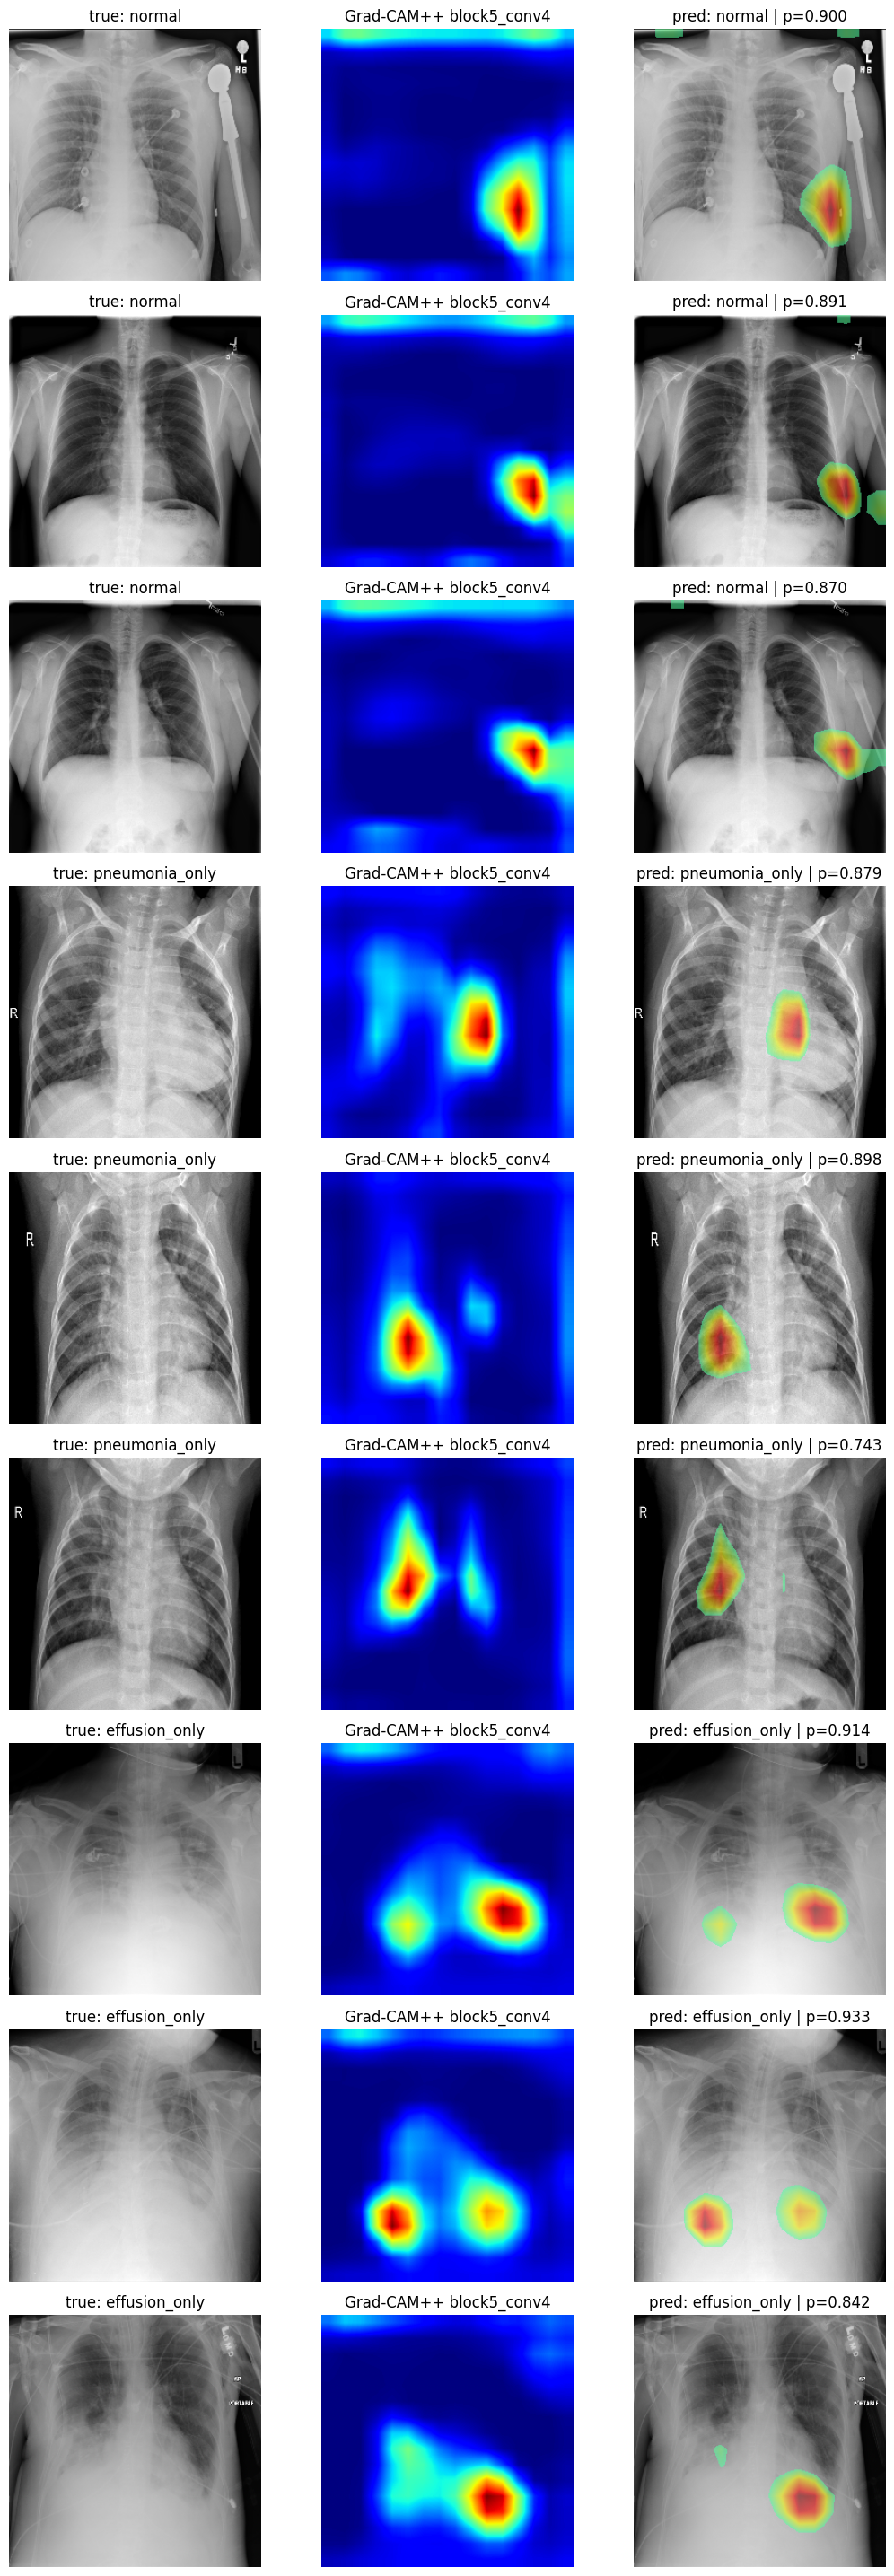

saved: /kaggle/working/report_vgg19_commonv2_gradcampp_fact/figures/vgg19_commonv2_gradcampp_examples.png


In [5]:
def collect_examples(per_class=3, scan_limit=900):
    candidates_by_class = {idx: [] for idx in range(len(CLASS_NAMES))}
    for idx, (path, label) in enumerate(zip(paths[:scan_limit], labels[:scan_limit])):
        display_rgb, model_input = decode_display_and_model(path)
        display_np = display_rgb.numpy().astype(np.float32)
        input_batch = model_input[None, ...]
        probs = model.predict(input_batch, verbose=0)
        if isinstance(probs, (list, tuple)):
            probs = probs[0]
        probs = probs[0]
        pred_index = int(np.argmax(probs))
        if pred_index != int(label):
            continue
        heatmap = resize_heatmap(make_gradcampp_heatmap(model, input_batch, pred_index))
        if int(np.sum(heatmap >= HEATMAP_THRESHOLD)) < 20:
            continue
        candidates_by_class[int(label)].append({
            "idx": idx,
            "path": path,
            "label": int(label),
            "pred_index": pred_index,
            "probs": probs,
            "display_np": display_np,
            "heatmap": heatmap,
            "border_score": heatmap_border_score(heatmap),
            "central_score": float(np.mean(heatmap[40:216, 28:228])),
        })
    selected = []
    for class_idx in range(len(CLASS_NAMES)):
        class_candidates = sorted(
            candidates_by_class[class_idx],
            key=lambda x: (x["border_score"], -x["central_score"], -float(x["probs"][x["pred_index"]])),
        )
        if len(class_candidates) < per_class:
            print(f"Warning: only found {len(class_candidates)} correct {CLASS_NAMES[class_idx]} examples.")
        selected.extend(class_candidates[:per_class])
    if not selected:
        raise ValueError("No correctly predicted examples found.")
    return sorted(selected, key=lambda x: (x["label"], x["border_score"], -x["central_score"]))


examples = collect_examples(per_class=3, scan_limit=900)
fig, axes = plt.subplots(len(examples), 3, figsize=(11, 3.2 * len(examples)))
if len(examples) == 1:
    axes = np.expand_dims(axes, axis=0)
records = []
for row, item in enumerate(examples):
    probs = item["probs"]
    label = item["label"]
    pred = item["pred_index"]
    overlay = overlay_heatmap(item["display_np"], item["heatmap"])
    axes[row, 0].imshow(item["display_np"].astype(np.uint8)); axes[row, 0].set_title(f"true: {CLASS_NAMES[label]}")
    axes[row, 1].imshow(item["heatmap"], cmap="jet", vmin=0, vmax=1); axes[row, 1].set_title(f"Grad-CAM++ {GRADCAM_LAYER}")
    axes[row, 2].imshow(overlay); axes[row, 2].set_title(f"pred: {CLASS_NAMES[pred]} | p={probs[pred]:.3f}")
    for ax in axes[row]:
        ax.axis("off")
    records.append({
        "row": int(item["idx"]),
        "path": item["path"],
        "true": CLASS_NAMES[label],
        "pred": CLASS_NAMES[pred],
        "pred_prob": float(probs[pred]),
        "border_score": float(item["border_score"]),
        "central_score": float(item["central_score"]),
    })
plt.tight_layout()
fig_path = FIGURE_DIR / "vgg19_commonv2_gradcampp_examples.png"
fig.savefig(fig_path, dpi=180, bbox_inches="tight")
plt.show()
pd.DataFrame(records).to_csv(ARTIFACT_DIR / "vgg19_commonv2_gradcampp_examples.csv", index=False)
print("saved:", fig_path)


,fraction_deleted,mean_target_prob,mean_prob_drop,deletion_auc
0,0.0,0.783064,1.396984e-09,0.453555
1,0.1,0.670685,1.123791e-01,0.453555
2,0.2,0.626777,1.562875e-01,0.453555
3,0.3,0.586119,1.969450e-01,0.453555
4,0.4,0.513877,2.691873e-01,0.453555
5,0.5,0.475959,3.071054e-01,0.453555
6,0.6,0.432431,3.506335e-01,0.453555
7,0.7,0.373367,4.096968e-01,0.453555
8,0.8,0.318256,4.648080e-01,0.453555
9,0.9,0.293098,4.899665e-01,0.453555


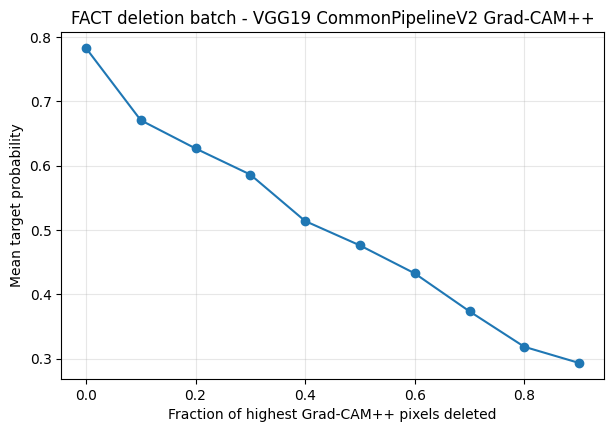

saved: /kaggle/working/report_vgg19_commonv2_gradcampp_fact/figures/vgg19_commonv2_gradcampp_fact_deletion_batch.png


In [6]:
def delete_by_heatmap_batch(model_inputs, heatmaps, fractions):
    model_inputs = np.asarray(model_inputs, dtype=np.float32)
    heatmaps = np.asarray(heatmaps, dtype=np.float32)
    baseline = np.zeros_like(model_inputs, dtype=np.float32)
    flat = heatmaps.reshape((heatmaps.shape[0], -1))
    order = np.argsort(-flat, axis=1)
    deleted_batches = []
    for fraction in fractions:
        deleted = model_inputs.copy()
        k = int(round(fraction * flat.shape[1]))
        if k > 0:
            for i in range(model_inputs.shape[0]):
                mask_flat = np.zeros(flat.shape[1], dtype=bool)
                mask_flat[order[i, :k]] = True
                mask = mask_flat.reshape((IMAGE_SIZE, IMAGE_SIZE))
                deleted[i, mask, :] = baseline[i, mask, :]
        deleted_batches.append(deleted)
    return deleted_batches


def fact_deletion_batch(max_images=64, fractions=None):
    if fractions is None:
        fractions = np.linspace(0.0, 0.9, 10)
    n = min(max_images, len(paths))
    model_inputs, target_indices, base_probs, heatmaps = [], [], [], []
    for i, path in enumerate(paths[:n]):
        true_label = int(labels[i])
        _, model_input = decode_display_and_model(path)
        input_batch = model_input[None, ...]
        probs = model.predict(input_batch, verbose=0)
        if isinstance(probs, (list, tuple)):
            probs = probs[0]
        probs = probs[0]
        target = true_label  # use true label, not argmax
        heatmaps.append(resize_heatmap(make_gradcampp_heatmap(model, input_batch, target)))
        model_inputs.append(model_input.numpy())
        target_indices.append(target)
        base_probs.append(float(probs[target]))
    model_inputs = np.stack(model_inputs).astype(np.float32)
    heatmaps = np.stack(heatmaps).astype(np.float32)
    target_indices = np.asarray(target_indices, dtype=np.int32)
    base_probs = np.asarray(base_probs, dtype=np.float32)
    rows = []
    for fraction, deleted in zip(fractions, delete_by_heatmap_batch(model_inputs, heatmaps, fractions)):
        probs = model.predict(deleted, batch_size=BATCH_SIZE, verbose=0)
        if isinstance(probs, (list, tuple)):
            probs = probs[0]
        target_probs = probs[np.arange(n), target_indices]
        rows.append({
            "fraction_deleted": float(fraction),
            "mean_target_prob": float(np.mean(target_probs)),
            "mean_prob_drop": float(np.mean(base_probs - target_probs)),
        })
    result = pd.DataFrame(rows)
    x = result["fraction_deleted"].to_numpy(dtype=np.float32)
    y = result["mean_target_prob"].to_numpy(dtype=np.float32)
    result["deletion_auc"] = float(
        np.trapezoid(y, x) if hasattr(np, "trapezoid") else np.sum((x[1:] - x[:-1]) * (y[1:] + y[:-1]) / 2.0)
    )
    return result


deletion_df = fact_deletion_batch()
deletion_df.to_csv(ARTIFACT_DIR / "vgg19_commonv2_gradcampp_fact_deletion_batch.csv", index=False)
from IPython.display import display
display(deletion_df)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(deletion_df["fraction_deleted"], deletion_df["mean_target_prob"], marker="o")
ax.set_xlabel("Fraction of highest Grad-CAM++ pixels deleted")
ax.set_ylabel("Mean target probability")
ax.set_title("FACT deletion batch - VGG19 CommonPipelineV2 Grad-CAM++")
ax.grid(True, alpha=0.3)
plot_path = FIGURE_DIR / "vgg19_commonv2_gradcampp_fact_deletion_batch.png"
fig.savefig(plot_path, dpi=180, bbox_inches="tight")
plt.show()
print("saved:", plot_path)
